# 01 · Exploración del corpus consolidado

Notebook de exploración rápida del corpus multivariante de TASS 2020, ya consolidado
por `scripts/data/consolidate_dataset.py`.

**Este notebook corre de dos formas:**
- Si ya tienes `data/processed/tass2020_consolidado.csv` (generado con el script real
  sobre el corpus descargado de tass.sepln.org), lo carga y lo explora tal cual.
- Si **todavía no tienes el corpus real**, genera datos simulados con el mismo esquema
  (`id, texto, variedad, etiqueta`), solo para que el notebook sea reproducible y
  revisable desde ya, sin bloquear el avance a la espera de la licencia de datos.

No se usa esta data simulada para ninguna conclusión del proyecto, es solo para
dejar el notebook funcionando de punta a punta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RUTA_CORPUS = Path("../data/processed/tass2020_consolidado.csv")
VARIEDADES = ["ES", "MX", "PE", "CL", "CR", "UY"]
ETIQUETAS = ["POS", "NEG", "NEU"]

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 100

In [2]:
def generar_corpus_simulado(n_por_celda: int = 40, seed: int = 42) -> pd.DataFrame:
    """
    Genera un corpus de ejemplo con el mismo esquema que consolidate_dataset.py,
    SOLO para poder explorar la estructura del notebook antes de tener el corpus real.
    No usar estos textos para ninguna conclusión del proyecto.
    """
    rng = np.random.default_rng(seed)
    textos_pos = [
        "Que lindo dia, estoy feliz", "Me encanto, genial", "Excelente servicio, lo recomiendo",
        "Todo salio bien, contento con el resultado",
    ]
    textos_neg = [
        "No me gusto nada", "Pesimo, nunca regreso", "Que mal rato pase",
        "No fue bueno, una decepcion total",
    ]
    textos_neu = [
        "Esta normal nomas", "No se, mas o menos", "Regular el dia", "Ahi va, nada especial",
    ]
    banco = {"POS": textos_pos, "NEG": textos_neg, "NEU": textos_neu}

    filas = []
    id_actual = 1
    for variedad in VARIEDADES:
        for etiqueta in ETIQUETAS:
            # Desbalance deliberado para que el notebook muestre algo interesante:
            # Peru (PE) queda con menos ejemplos, como advierte el avance de la Semana 2.
            n = n_por_celda // 2 if variedad == "PE" else n_por_celda
            for _ in range(n):
                texto = rng.choice(banco[etiqueta])
                filas.append({"id": id_actual, "texto": texto, "variedad": variedad, "etiqueta": etiqueta})
                id_actual += 1
    return pd.DataFrame(filas)


if RUTA_CORPUS.exists():
    df = pd.read_csv(RUTA_CORPUS)
    fuente = f"corpus real: {RUTA_CORPUS}"
else:
    df = generar_corpus_simulado()
    fuente = "corpus SIMULADO (no hay data real todavia en data/processed/)"

print(f"Fuente de los datos: {fuente}")
print(f"Filas: {len(df)}")
df.head()

Fuente de los datos: corpus SIMULADO (no hay data real todavia en data/processed/)
Filas: 660


,id,texto,variedad,etiqueta
0,1,"Que lindo dia, estoy feliz",ES,POS
1,2,"Todo salio bien, contento con el resultado",ES,POS
2,3,"Excelente servicio, lo recomiendo",ES,POS
3,4,"Me encanto, genial",ES,POS
4,5,"Me encanto, genial",ES,POS


## Distribución por variedad dialectal

El avance de la Semana 2 advierte que la variedad peruana es la candidata más probable
a tener menos representación. Este gráfico sirve para confirmarlo apenas se tenga el
corpus real, antes de reportar cualquier métrica por país.

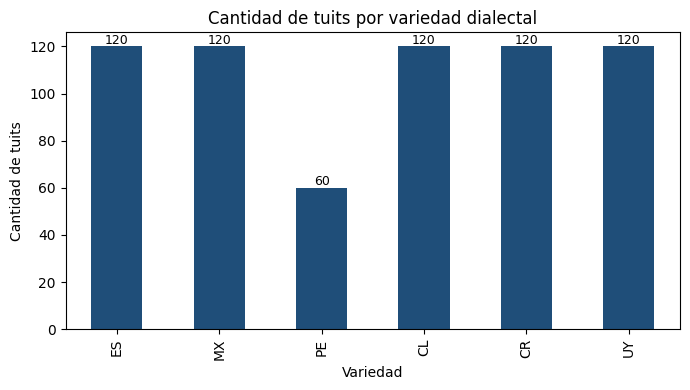

variedad
ES    120
MX    120
PE     60
CL    120
CR    120
UY    120
Name: count, dtype: int64

In [3]:
conteo_variedad = df["variedad"].value_counts().reindex(VARIEDADES)

fig, ax = plt.subplots(figsize=(7, 4))
conteo_variedad.plot(kind="bar", ax=ax, color="#1F4E79")
ax.set_title("Cantidad de tuits por variedad dialectal")
ax.set_xlabel("Variedad")
ax.set_ylabel("Cantidad de tuits")
for i, v in enumerate(conteo_variedad.values):
    ax.text(i, v + max(conteo_variedad.values) * 0.01, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

conteo_variedad

## Balance de clases por variedad

Util para decidir si el split estratificado (`scripts/data/split_dataset.py`) tiene
suficientes ejemplos de cada combinación variedad × etiqueta.

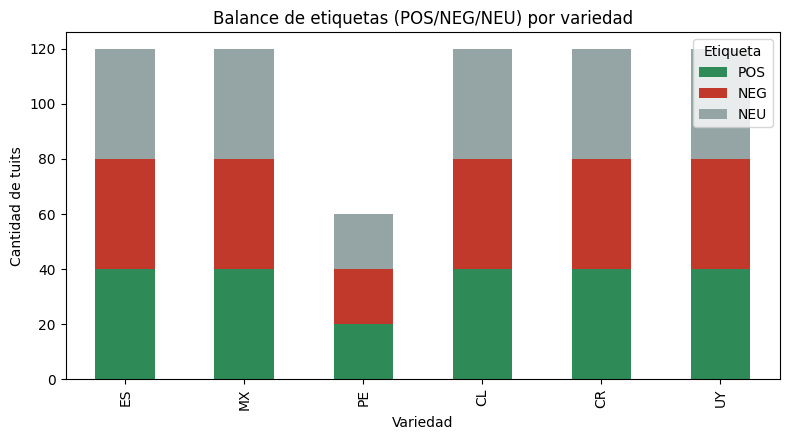

etiqueta,POS,NEG,NEU
variedad,,,
ES,40,40,40
MX,40,40,40
PE,20,20,20
CL,40,40,40
CR,40,40,40
UY,40,40,40


In [4]:
tabla_balance = pd.crosstab(df["variedad"], df["etiqueta"]).reindex(VARIEDADES)[ETIQUETAS]

fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_balance.plot(kind="bar", stacked=True, ax=ax, color=["#2E8B57", "#C0392B", "#95A5A6"])
ax.set_title("Balance de etiquetas (POS/NEG/NEU) por variedad")
ax.set_xlabel("Variedad")
ax.set_ylabel("Cantidad de tuits")
ax.legend(title="Etiqueta")
plt.tight_layout()
plt.show()

tabla_balance

## Longitud de los textos

Para tener una idea de cuánto varía la longitud de los tuits entre variedades, algo
relevante para fijar el `contexto_maximo_tokens` en `configs/model_config.yaml`.

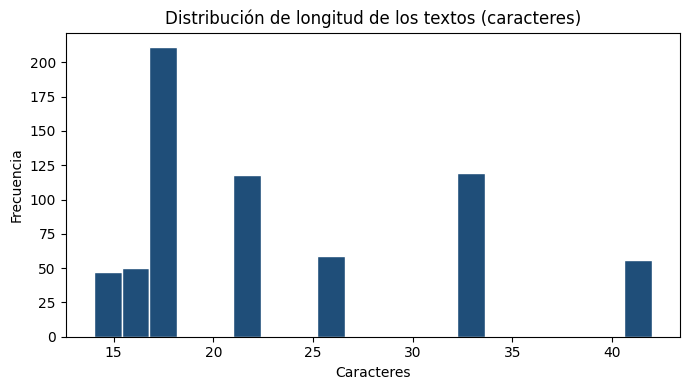

,mean,min,max
variedad,,,
CL,23.325000,14.0,42.0
CR,23.741667,14.0,42.0
ES,23.541667,14.0,42.0
MX,22.858333,14.0,42.0
PE,22.716667,14.0,42.0
UY,23.883333,14.0,42.0


In [5]:
df["longitud_caracteres"] = df["texto"].str.len()

fig, ax = plt.subplots(figsize=(7, 4))
df["longitud_caracteres"].plot(kind="hist", bins=20, ax=ax, color="#1F4E79", edgecolor="white")
ax.set_title("Distribución de longitud de los textos (caracteres)")
ax.set_xlabel("Caracteres")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

df.groupby("variedad")["longitud_caracteres"].describe()[["mean", "min", "max"]]

## Ejemplos por variedad y etiqueta

Una muestra rápida para revisar a simple vista, antes de pasar al script
`audit_phenomena.py` (que cuenta heurísticamente sarcasmo, diminutivos, code-switching
y doble negación sobre el conjunto de desarrollo).

In [6]:
for variedad in VARIEDADES:
    print(f"\n=== {variedad} ===")
    muestra = df[df["variedad"] == variedad].groupby("etiqueta").head(1)
    for _, fila in muestra.iterrows():
        print(f"  [{fila['etiqueta']}] {fila['texto']}")


=== ES ===
  [POS] Que lindo dia, estoy feliz
  [NEG] No me gusto nada
  [NEU] Ahi va, nada especial

=== MX ===
  [POS] Me encanto, genial
  [NEG] No fue bueno, una decepcion total
  [NEU] No se, mas o menos

=== PE ===
  [POS] Que lindo dia, estoy feliz
  [NEG] No fue bueno, una decepcion total
  [NEU] No se, mas o menos

=== CL ===
  [POS] Me encanto, genial
  [NEG] Que mal rato pase
  [NEU] Esta normal nomas

=== CR ===
  [POS] Todo salio bien, contento con el resultado
  [NEG] Que mal rato pase
  [NEU] Esta normal nomas

=== UY ===
  [POS] Excelente servicio, lo recomiendo
  [NEG] No me gusto nada
  [NEU] No se, mas o menos


## Próximos pasos

1. Reemplazar la data simulada: descargar el corpus real en tass.sepln.org, colocarlo
   en `data/raw/<variedad>/` y correr `scripts/data/consolidate_dataset.py`.
2. Re-correr este notebook contra `data/processed/tass2020_consolidado.csv` real y
   revisar si el desbalance de PE (u otra variedad) es tan marcado como en el ejemplo.
3. Correr `scripts/data/split_dataset.py` para generar dev/val/test.
4. Correr `scripts/data/audit_phenomena.py` sobre `dev.csv` y revisar manualmente una
   muestra de lo que el script marca como sarcasmo/diminutivo/code-switching, antes
   de diseñar los prompts de los agentes (`agents/`).